In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
df=pd.read_csv('https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/2014-15_To_2016-17_School-_Level_NYC_Regents_Report_For_All_Variables.csv')

In [ ]:
df.head()

In [ ]:
df.columns

Index(['School DBN', 'School Name', 'School Level', 'Regents Exam', 'Year',
       'Total Tested', 'Mean Score', 'Number Scoring Below 65',
       'Percent Scoring Below 65', 'Number Scoring 65 or Above',
       'Percent Scoring 65 or Above', 'Number Scoring 80 or Above',
       'Percent Scoring 80 or Above', 'Number Scoring CR',
       'Percent Scoring CR'],
      dtype='object')

In [ ]:
#achieved the College Readiness score

In [ ]:
df['borough'] = df['School DBN'].str[2]

In [ ]:
df.isnull().sum()

School DBN                          0
School Name                         0
School Level                        0
Regents Exam                       10
Year                                0
Total Tested                        0
Mean Score                      75222
Number Scoring Below 65         75222
Percent Scoring Below 65        75222
Number Scoring 65 or Above      75222
Percent Scoring 65 or Above     75222
Number Scoring 80 or Above      75222
Percent Scoring 80 or Above     75222
Number Scoring CR              142680
Percent Scoring CR             142680
borough                             0
dtype: int64

In [ ]:
#convert non-numeric types (e.g., strings or objects) in a list, tuple, 1-d array,
#or pd Series to a suitable numeric type (typically int64 or float64),forcing non-parsable values (strings, symbols) into NaN
cols = ['Year','Total Tested', 'Mean Score',
        'Number Scoring Below 65',
       'Percent Scoring Below 65', 'Number Scoring 65 or Above',
       'Percent Scoring 65 or Above', 'Number Scoring 80 or Above',
       'Percent Scoring 80 or Above', 'Number Scoring CR',
       'Percent Scoring CR']
for col in cols:
  df[col]= pd.to_numeric(df[col], errors = 'coerce')

In [ ]:
# drop rows if specific columns have NaN
df2 = df.dropna(subset = ['Mean Score', 'Regents Exam',
                          'Number Scoring CR','Percent Scoring CR'])

In [ ]:
#rename cols
df2 = df2.rename(columns={'Percent Scoring Below 65':'scoring below 65 in %',
                          'Percent Scoring 65 or Above': 'scoring 65 or above in %',
                          'Percent Scoring 80 or Above':'scoring 80 or above in %',
                          'Percent Scoring CR':'% scoring CR'})
df2.head(10)

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,scoring below 65 in %,Number Scoring 65 or Above,scoring 65 or above in %,Number Scoring 80 or Above,scoring 80 or above in %,Number Scoring CR,% scoring CR,borough
8,01M184,P.S. 184m Shuang Wen,K-8,Common Core Algebra,2015,49,78.4,1.0,2.0,48.0,98.0,23.0,46.9,48.0,98.0,M
9,01M184,P.S. 184m Shuang Wen,K-8,Common Core Algebra,2016,51,79.0,9.0,17.6,42.0,82.4,33.0,64.7,40.0,78.4,M
10,01M184,P.S. 184m Shuang Wen,K-8,Common Core Algebra,2017,51,84.8,0.0,0.0,51.0,100.0,44.0,86.3,50.0,98.0,M
12,01M188,P.S. 188 The Island School,K-8,Common Core Algebra,2015,23,62.9,14.0,60.9,9.0,39.1,0.0,0.0,2.0,8.7,M
13,01M188,P.S. 188 The Island School,K-8,Common Core Algebra,2016,22,69.0,6.0,27.3,16.0,72.7,2.0,9.1,15.0,68.2,M
14,01M188,P.S. 188 The Island School,K-8,Common Core Algebra,2017,20,67.4,7.0,35.0,13.0,65.0,1.0,5.0,10.0,50.0,M
20,01M292,Orchard Collegiate Academy,High school,Common Core Algebra,2015,12,52.3,11.0,91.7,1.0,8.3,0.0,0.0,0.0,0.0,M
21,01M292,Orchard Collegiate Academy,High school,Common Core Algebra,2016,50,63.9,25.0,50.0,25.0,50.0,3.0,6.0,15.0,30.0,M
22,01M292,Orchard Collegiate Academy,High school,Common Core Algebra,2017,53,67.5,15.0,28.3,38.0,71.7,6.0,11.3,29.0,54.7,M
23,01M292,Orchard Collegiate Academy,High school,Common Core Algebra2,2016,6,48.0,6.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,M


In [ ]:
df2.isnull().sum()

,0
School DBN,0
School Name,0
School Level,0
Regents Exam,0
Year,0
Total Tested,0
Mean Score,0
Number Scoring Below 65,0
scoring below 65 in %,0
Number Scoring 65 or Above,0


In [ ]:
#df2['School Level'].unique()
df2['Regents Exam'].unique()

array(['Common Core Algebra', 'Common Core Algebra2',
       'Common Core English', 'Common Core Geometry', 'English',
       'Geometry', 'Integrated Algebra', 'Algebra2/Trigonometry'],
      dtype=object)

In [ ]:
df2.groupby(['School DBN','Regents Exam'])['Mean Score'].max().sort_values(ascending=False)

,,Mean Score
School DBN,Regents Exam,
04M555,Common Core English,98.3
25Q525,Common Core English,96.9
14K449,Common Core English,96.8
28Q687,Common Core English,96.7
10X445,Common Core Algebra,96.6
...,...,...
09X329,Algebra2/Trigonometry,32.0
14K610,Algebra2/Trigonometry,30.7
19K507,Algebra2/Trigonometry,29.2


In [ ]:
df2.groupby(['School DBN','School Level','School Name'])['Total Tested'].sum().sort_values(ascending=False).head(3)


,,,Total Tested
School DBN,School Level,School Name,
26Q495,High school,Bayside High School,78594
13K430,High school,Brooklyn Technical High School,78066
26Q430,High school,Francis Lewis High School,73224


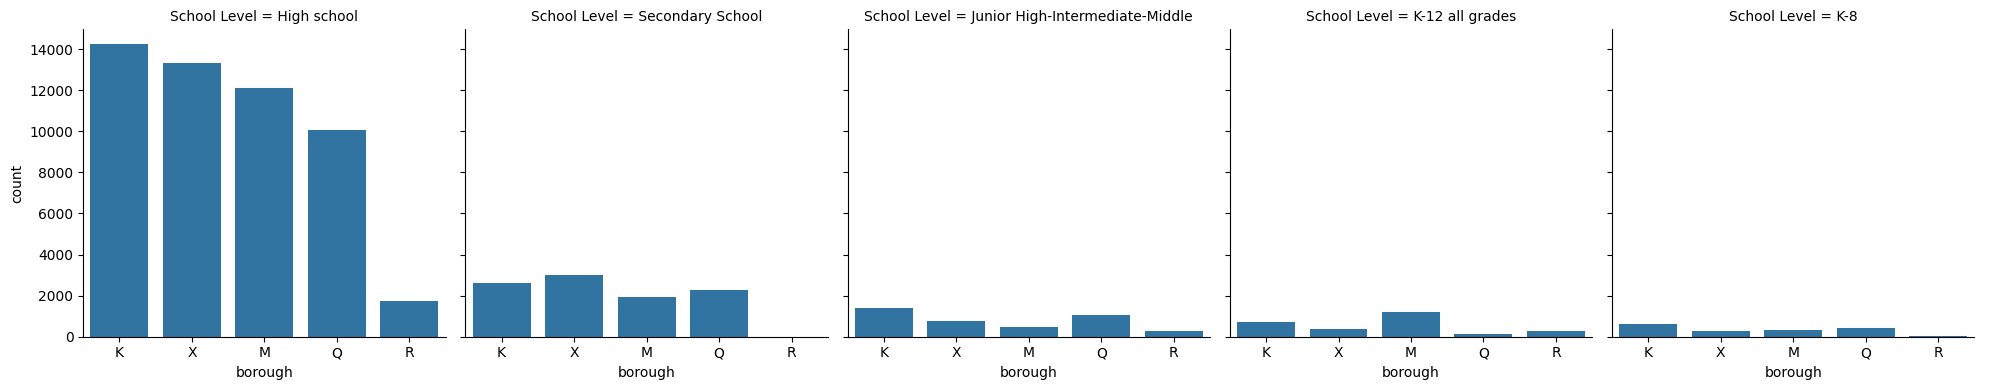

In [ ]:
by_b = df2.groupby(['borough','School Level'])['scoring 80 or above in %'].count().sort_values(ascending=False).reset_index(name='count')
sns.catplot(data=by_b, x='borough', y='count',
            col='School Level', kind='bar', height=4)
plt.show()

The level of students who score 80 or above are most tested at high school level. Amount of students in descending order, most of the students studies in Kings, following by Bronx, Manhattan, Queens and Staten Island.

Text(0.5, 1.04, 'Mean score of regents exam at Bayside High School (2015-2017)')

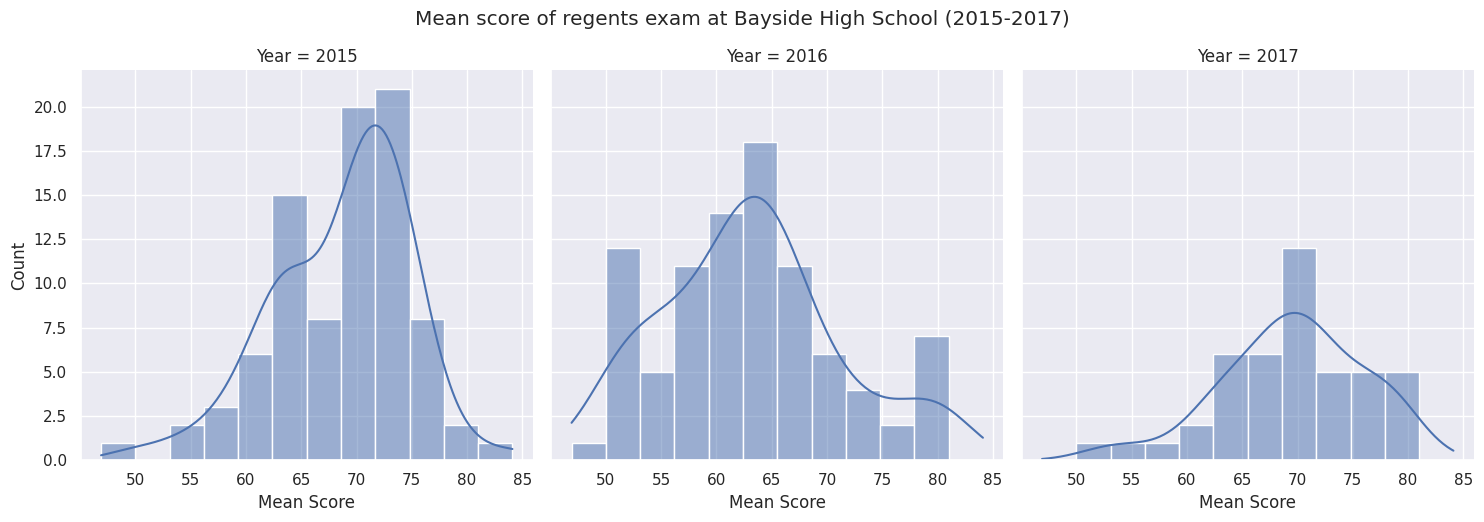

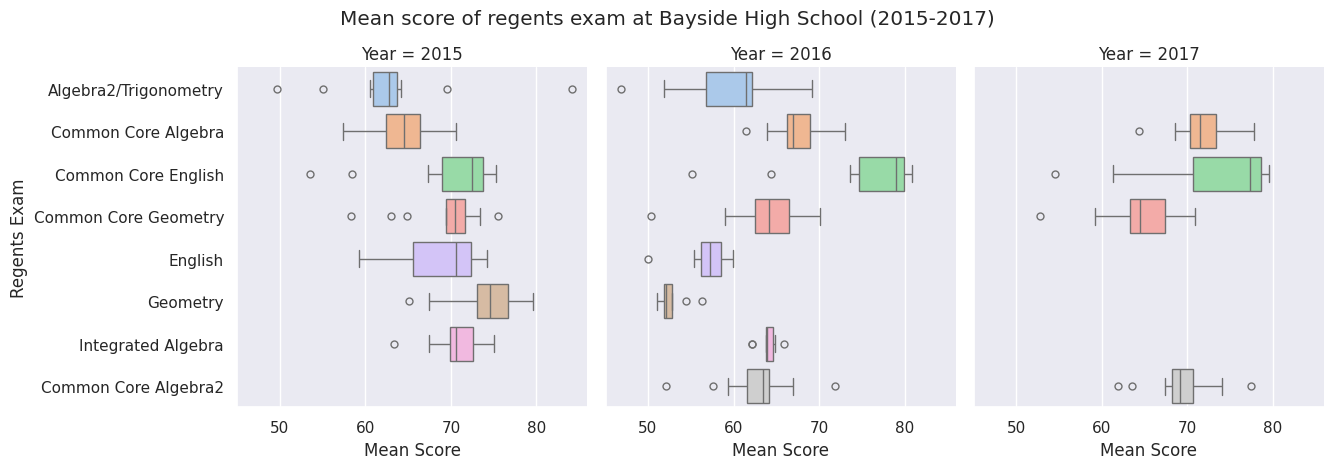

In [ ]:
#Bayside High School 26Q495 #vars=['Total Tested','Mean Score','Number Scoring 65 or Above'],hue ='Year'

#sch = school.drop(columns=['School DBN','School Name','School Level',
                           #'Number Scoring Below 65','scoring below 65 in %','Number Scoring 65 or Above',
                           #'Number Scoring 80 or Above','Number Scoring CR','borough'])

school = df2[df2['School DBN'] == '26Q495'].sort_values(['Year',
                                                         'Regents Exam'])
a = sns.displot(data=school, x='Mean Score',
                col = 'Year',kde=True)#,plot_kws={'line_kws':{'color':'red'}}
a.fig.suptitle('Mean score of regents exam at Bayside High School (2015-2017)', y=1.04)

b = sns.catplot(data=school, x='Mean Score', y='Regents Exam',
                col='Year',hue='Regents Exam', kind='box',
                palette="pastel",height=4.5)
b.fig.suptitle('Mean score of regents exam at Bayside High School (2015-2017)', y=1.04)

At Bayside High School, majority of scores were high in 2015 (left-skewed distribution), indicates most of the students did good in exam. Whereas the distribution skewed right in 2016, student did worse on couple subjects, especially Geometry and English; the majority of mean score below 65 (50-60). The count of mean score in 2017 was lower due to fewer exams.

In [ ]:
#subset of NYC high schools and subset of high schools in Queens
high_sch = df2[df2['School Level'] == 'High school'].sort_values('Regents Exam')
bor_q = high_sch[high_sch['borough'] == 'Q'].sort_values('Regents Exam')

In [ ]:
school.describe()

In [ ]:
high_sch.describe()

In [ ]:
bor_q.describe()

Text(0.5, 1.06, 'scoring 80 or above in % in Queens high schools 2015-2017')

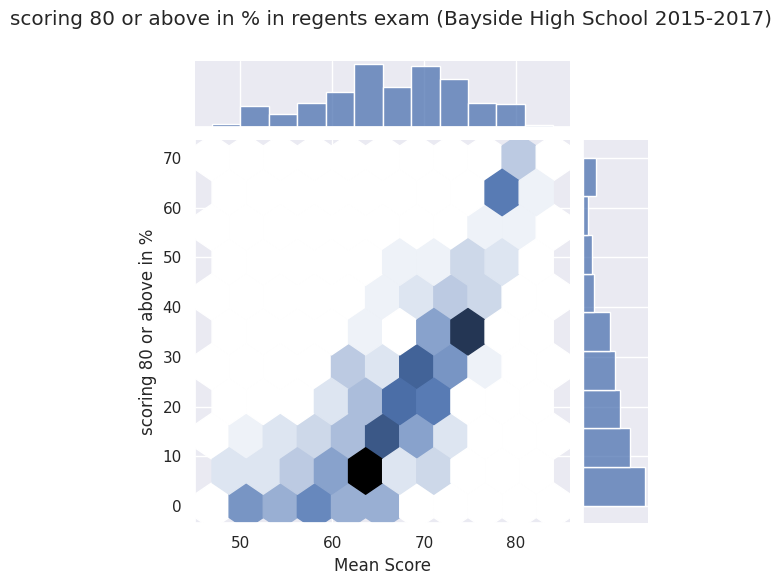

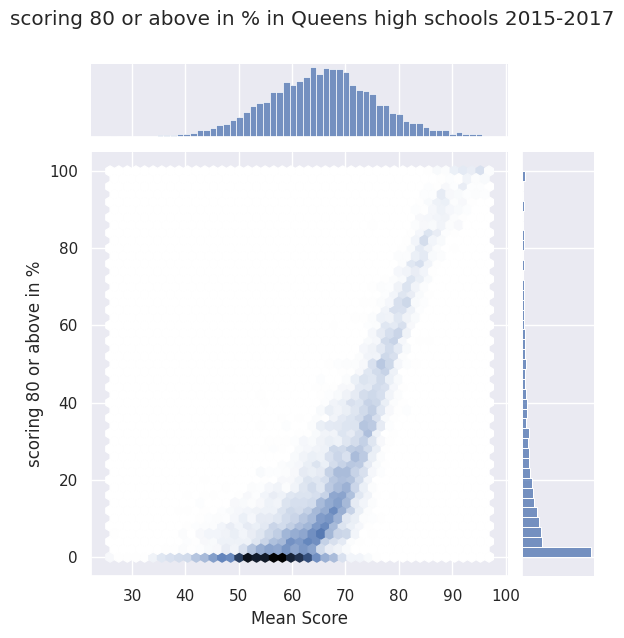

In [ ]:
#Bayside High School percent scoring below 65

c = sns.jointplot(x = 'Mean Score', y = 'scoring 80 or above in %',
                kind = 'hex',height=5.5, data = school)
c.fig.suptitle("scoring 80 or above in % in regents exam (Bayside High School 2015-2017)", y=1.06)


#bor_q['2015'] = bor_q[bor_q['Year'] == '2015']
d = sns.jointplot(x = 'Mean Score', y = 'scoring 80 or above in %',
                 kind = 'hex',data = bor_q)
d.fig.suptitle("scoring 80 or above in % in Queens high schools 2015-2017", y=1.06)

Overall students at Bayside HS did better than students in Queens high schools. There are two darkest shape(highest value):above 10% of students(y-axis) score above 80 and with a mean score near 65, the other group above 40% of students scoring 80 or higher had a mean score>70. Whereas high school students in queens have a wider range of mean score between 50-60, less than 10% of students score above 80.

Text(0.5, 1.04, 'Mean Score at Bayside High School(2015-2017)')

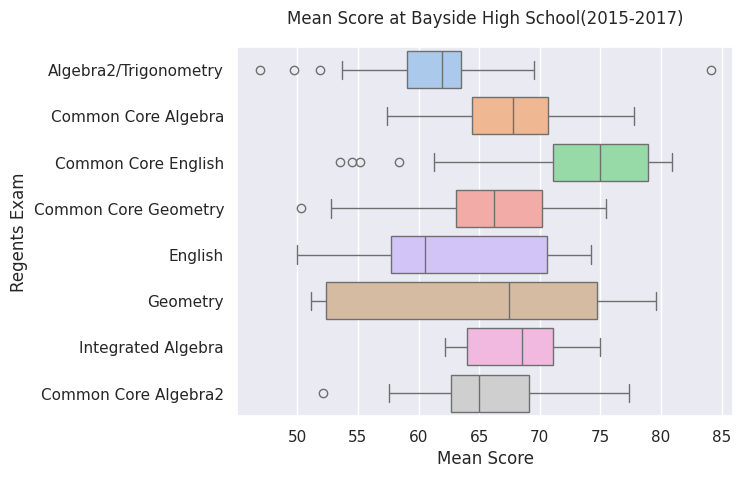

In [ ]:
#Bayside High School 26Q495
e = sns.boxplot(data=school, x='Mean Score', y='Regents Exam',
                hue='Regents Exam', palette="pastel")
e.set_title('Mean Score at Bayside High School(2015-2017)',y = 1.04)

Text(0.5, 1.04, 'Mean Score in NYC High Schools(2015-2017)')

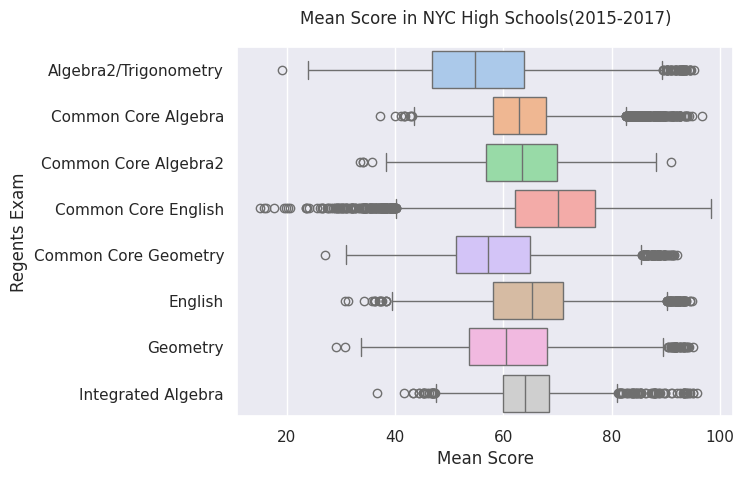

In [ ]:
#Regents exam at NYC High School
c = sns.boxplot(data=high_sch, x='Mean Score', y='Regents Exam',
                hue='Regents Exam', palette="pastel")
c.set_title('Mean Score in NYC High Schools(2015-2017)', y=1.04)

Comparing boxplots of Bayside HS and NYC high school(NYC HS):
The data of NYC HS is more symmetrical, both half-boxes and whiskers are almost the same length. Data are more concentrate; most of the subjects, students with a mean score betweeen 60-70 constitutes the interquartile range (50%, IQR).
Box length of Bayside HS are varies and longer, the median of most of the boxplot is above mean score of 65, perform better than NYC high schools in general.
All three distributions include potential outliers.

Text(0.5, 1.04, 'Mean Score in Queens borough (high schools 2015-2017)')

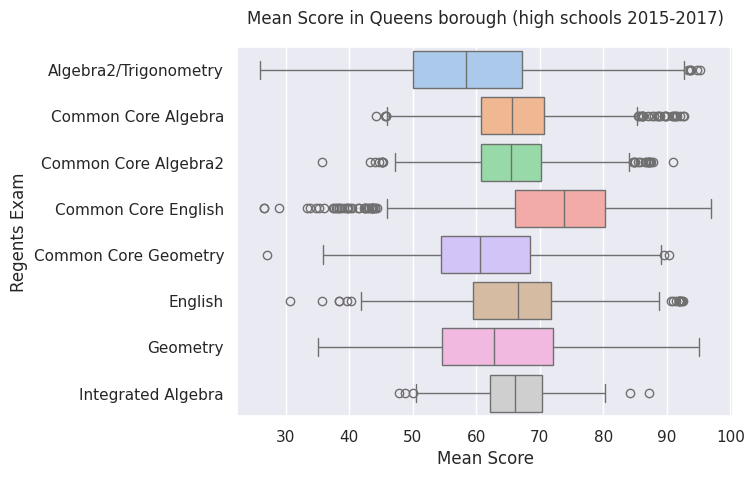

In [ ]:
#Regents exam of high schools in Queens
d = sns.boxplot(data=bor_q, x='Mean Score', y='Regents Exam',
                hue='Regents Exam', palette="pastel")
d.set_title('Mean Score in Queens borough (high schools 2015-2017)', y=1.04)